In [14]:
import os
os.environ["OMP_NUM_THREADS"] = "6"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.lines as mlines

from sklearn.decomposition import PCA

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

from collections import Counter
from scipy.stats import chi2_contingency

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()


#für Hierarchisches Clustering
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

In [15]:
#angepasst auf finale datei
seq_regions = ['SEQ_H1', 'SEQ_H2', 'SEQ_L1', 'SEQ_L2', 'SEQ_L3']
cf_regions = ['CF_H1', 'CF_H2', 'CF_L1', 'CF_L2', 'CF_L3']
df = (
    pd.read_csv("data/ab_ag_scalop.tsv", sep="\t")
    .dropna(subset=seq_regions)
    .dropna(subset=cf_regions)
    .drop_duplicates(subset=seq_regions) 
)
antigen_labels = df["antigen_name"].tolist()


In [17]:
#häufigkeiten in cf überprüfen
cf_regions = ["CF_H1","CF_H2", "CF_L1", "CF_L2", "CF_L3"]
for col in cf_regions:
    print(f"\nVerteilung der Canonical Forms in {col}:")
    print(df[col].value_counts())



Verteilung der Canonical Forms in CF_H1:
CF_H1
H1-7-A    801
H1-7-C    291
H1-9-A     73
H1-7-D     38
H1-9-B     28
H1-8-B     12
H1-8-A      9
H1-7-B      2
Name: count, dtype: int64

Verteilung der Canonical Forms in CF_H2:
CF_H2
H2-6-A    439
H2-5-A    319
H2-6-B    303
H2-6-D     81
H2-6-C     62
H2-8-A     25
H2-6-E     25
Name: count, dtype: int64

Verteilung der Canonical Forms in CF_L1:
CF_L1
L1-11-A       619
L1-14-A       111
L1-12-B       108
L1-16,17-A    100
L1-11-B        99
L1-13-A        73
L1-12-A        43
L1-14-C        30
L1-15-A        24
L1-13-B        24
L1-10-A        14
L1-14-B         8
L1-13-C         1
Name: count, dtype: int64

Verteilung der Canonical Forms in CF_L2:
CF_L2
L2-7-A    1254
Name: count, dtype: int64

Verteilung der Canonical Forms in CF_L3:
CF_L3
L3-9,10-A     785
L3-10,11-A    180
L3-10-A        92
L3-8-A         79
L3-9-A         73
L3-5-A         20
L3-11-A        19
L3-10-B         6
Name: count, dtype: int64


✅ TSV-Datei für SEQ_H1 geschrieben: cdr_cluster_tsvs/clusters_SEQ_H1.tsv


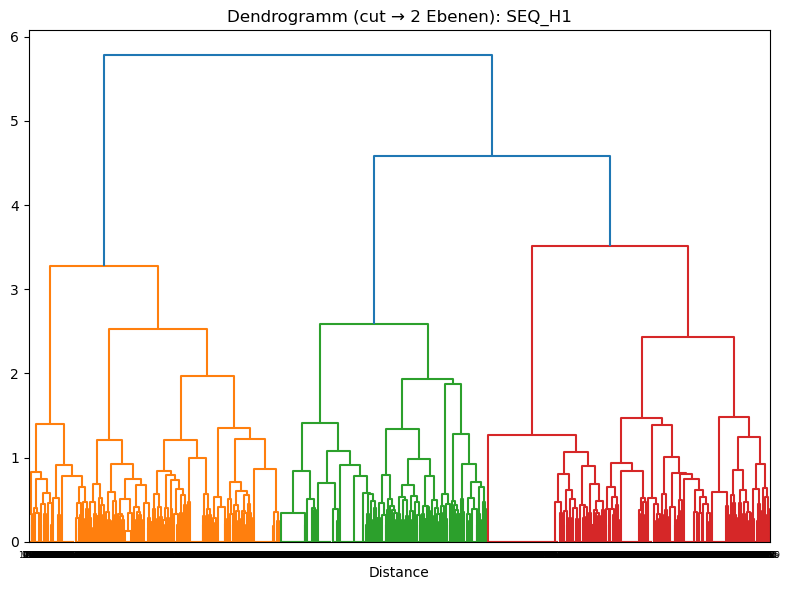


Teilbaum-Aufteilung für SEQ_H1 (2 Ebenen → 3 Teilbäume):

 Teilbaum (Cluster-ID 1):
  Antigen-Verteilung:
    spike protein s1: 74x
    spike glycoprotein: 72x
    hemagglutinin: 26x
    surface glycoprotein: 15x
    neuraminidase: 10x
    spike glycoprotein,fibritin: 6x
    nucleoprotein: 6x
    fusion glycoprotein f0: 4x
    epidermal growth factor receptor: 4x
    reticulocyte-binding protein homolog 5: 4x
    envelope glycoprotein b: 4x
    spike protein s2': 3x
    lysozyme c: 3x
    gp38: 3x
    envelope glycoprotein e2: 3x
    25 kda ookinete surface antigen: 3x
    interleukin-13: 3x
    interleukin-2: 3x
    outer surface protein a: 3x
    gametocyte surface protein p230: 3x
    ige fc: 3x
    envelopment polyprotein: 2x
    spike glycoprotein s1: 2x
    spike protein: 2x
    envelope glycoprotein e: 2x
    glutamate receptor ionotropic, nmda 1: 2x
    isoform 2b of gtpase kras: 2x
    gametocyte surface protein p45/48: 2x
    iron-regulated surface determinant protein b: 2x


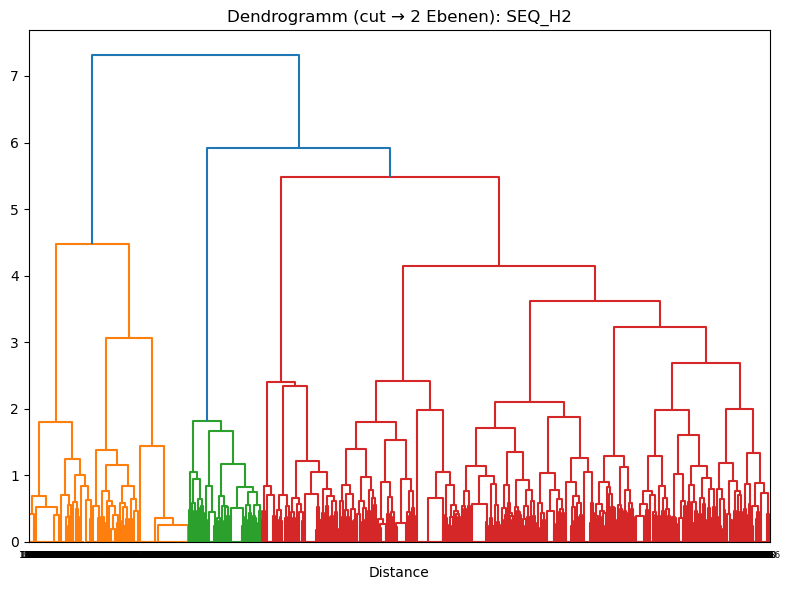


Teilbaum-Aufteilung für SEQ_H2 (2 Ebenen → 3 Teilbäume):

 Teilbaum (Cluster-ID 1):
  Antigen-Verteilung:
    spike protein s1: 52x
    spike glycoprotein: 30x
    hemagglutinin: 10x
    surface glycoprotein: 8x
    neuraminidase: 5x
    nucleoprotein: 4x
    circumsporozoite protein: 4x
    lysozyme c: 4x
    histone chaperone asf1: 3x
    maltose-binding periplasmic protein: 3x
    epidermal growth factor receptor: 3x
    fusion glycoprotein f0: 3x
    gp38: 3x
    tumor necrosis factor receptor superfamily member 9: 3x
    receptor tyrosine-protein kinase erbb-2: 3x
    gametocyte surface protein p230: 3x
    reticulocyte binding protein 2b: 3x
    programmed cell death protein 1: 3x
    frizzled-7: 2x
    interleukin-2: 2x
    core protein: 2x
    voltage-sensor containing phosphatase: 2x
    spike glycoprotein s1: 2x
    hepatitis a virus cellular receptor 2: 2x
    9mer peptide,beta-2-microglobulin,mhc class i antigenchimera : 2x
    erythropoietin receptor: 2x
    leukocyte sur

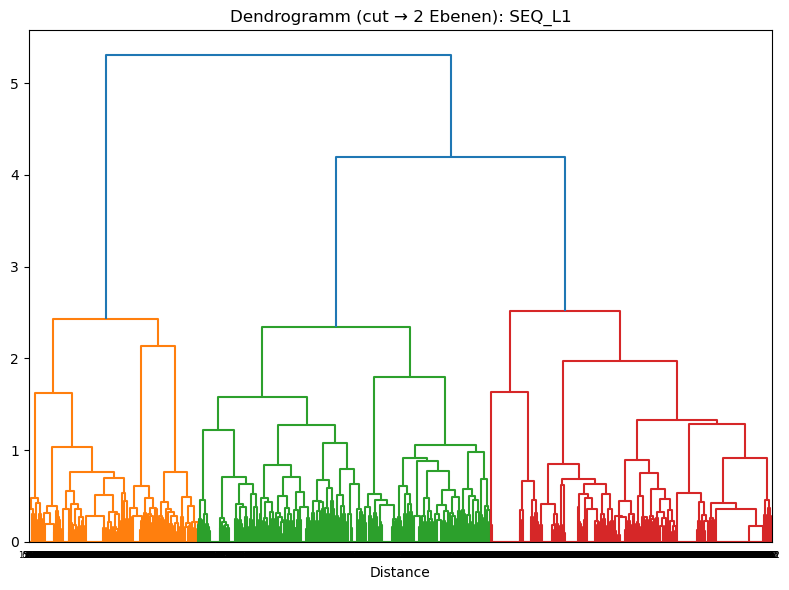


Teilbaum-Aufteilung für SEQ_L1 (2 Ebenen → 3 Teilbäume):

 Teilbaum (Cluster-ID 1):
  Antigen-Verteilung:
    spike glycoprotein: 59x
    spike protein s1: 49x
    hemagglutinin: 9x
    neuraminidase: 7x
    ch848.10.17 gp120: 6x
    circumsporozoite protein: 5x
    reticulocyte binding protein 2b: 5x
    spike glycoprotein,fibritin: 4x
    envelope glycoprotein gp120: 4x
    envelope glycoprotein b: 4x
    fusion glycoprotein f0: 3x
    lysozyme c: 3x
    surface glycoprotein: 3x
    envelope protein: 3x
    erythropoietin receptor: 3x
    ch848.10.17.sosip gp120: 3x
    hemagglutinin ha1 chain: 3x
    25 kda ookinete surface antigen: 2x
    sars-cov-2 spike glycoprotein: 2x
    hiv-1 bg505 ds-sosip glycoprotein gp120: 2x
    clade a/e 93th057 hiv-1 gp120 core: 2x
    envelope glycoprotein gp160: 2x
    nucleoprotein: 2x
    c-x-c motif chemokine 13: 2x
    phosphate-binding protein psts 1: 2x
    gametocyte surface protein p230: 2x
    hemagglutinin ha1: 2x
    duffy binding surface

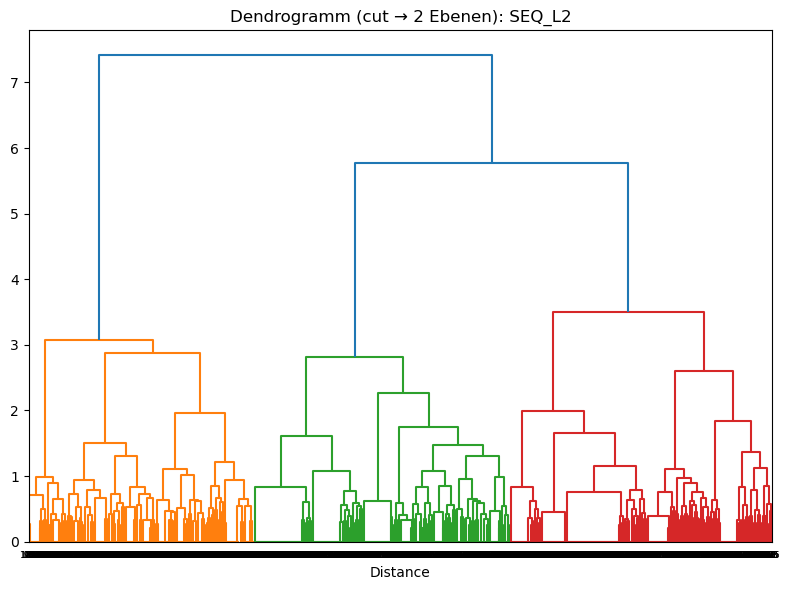


Teilbaum-Aufteilung für SEQ_L2 (2 Ebenen → 3 Teilbäume):

 Teilbaum (Cluster-ID 1):
  Antigen-Verteilung:
    spike glycoprotein: 70x
    spike protein s1: 60x
    hemagglutinin: 16x
    fusion glycoprotein f0: 9x
    neuraminidase: 7x
    surface glycoprotein: 5x
    circumsporozoite protein: 5x
    reticulocyte binding protein 2b: 5x
    envelope glycoprotein gp120: 5x
    envelope glycoprotein b: 5x
    ch848.10.17 gp120: 5x
    spike glycoprotein,fibritin: 4x
    25 kda ookinete surface antigen: 4x
    gametocyte surface protein p230: 4x
    hemagglutinin ha1 chain: 3x
    interleukin-17a: 3x
    erythropoietin receptor: 3x
    envelope protein: 3x
    envelope glycoprotein gp160: 3x
    ch848.10.17.sosip gp120: 3x
    sars-cov-2 spike glycoprotein: 3x
    lysozyme c: 3x
    conglutin: 2x
    receptor binding protein: 2x
    duffy binding surface protein region ii: 2x
    thyrotropin receptor: 2x
    reticulocyte-binding protein homolog 5: 2x
    hemagglutinin ha1: 2x
    epiderma

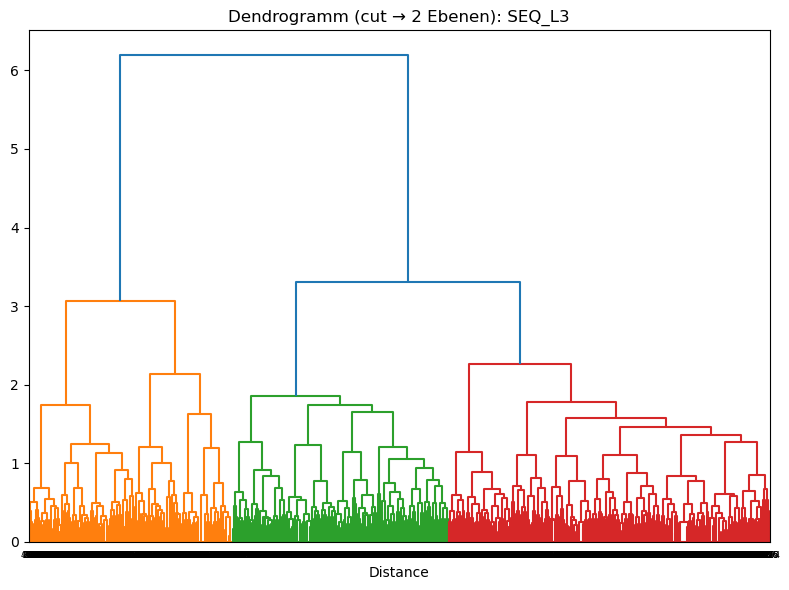


Teilbaum-Aufteilung für SEQ_L3 (2 Ebenen → 3 Teilbäume):

 Teilbaum (Cluster-ID 1):
  Antigen-Verteilung:
    spike glycoprotein: 66x
    spike protein s1: 58x
    hemagglutinin: 11x
    neuraminidase: 7x
    envelope glycoprotein gp120: 6x
    fusion glycoprotein f0: 6x
    ch848.10.17 gp120: 6x
    surface glycoprotein: 5x
    circumsporozoite protein: 5x
    spike glycoprotein,fibritin: 5x
    reticulocyte binding protein 2b: 5x
    envelope glycoprotein b: 4x
    envelope glycoprotein gp160: 4x
    nucleoprotein: 3x
    gametocyte surface protein p230: 3x
    sars-cov-2 spike glycoprotein: 3x
    hemagglutinin ha1 chain: 3x
    interleukin-17a: 3x
    ch848.10.17.sosip gp120: 3x
    lysozyme c: 3x
    receptor binding protein: 2x
    duffy binding surface protein region ii: 2x
    merozoite surface protein 1: 2x
    envelope protein: 2x
    phosphate-binding protein psts 1: 2x
    25 kda ookinete surface antigen: 2x
    glycoprotein: 2x
    erythropoietin receptor: 2x
    spike gl

In [ ]:
# Hierarchisches Clustering und Identifikation der farbigen Teilbäume

df = df.reset_index(drop=True)

# CDR-Spalten & Antigen-Spalte#
#cdr_columns = ['CDR_H1','CDR_H2','CDR_H3','CDR_L1','CDR_L2','CDR_L3']
#antigen_col = "antigen_name"

# Wie viele Fusionen vom Wurzelknoten wir runterscrollen wollen
levels_down = 2   # z.B. 2 Ebenen, so haben wir 3 teilbäume. das macht für H1 am meisten sinn

# Daten einlesen & unvollständige Zeilen entfernen
# zweite Zeile überflüssig, wenn Marcel data clean up korrekt gemacht hat
#df = pd.read_csv("data/df.tsv", sep='\t')
#df = df.dropna(subset=regions + [antigen_col]).reset_index(drop=True)


# AA-Häufigkeitsvektor-Funktion (20 Standard-AAs)
AA_LIST = list("ACDEFGHIKLMNPQRSTVWY")
def aa_freq_vector(seq: str) -> np.ndarray:   #aa_freq_vector name der Funktion, nimmt eine sequenz, die string sein soll, rückgabe ist np.ndarray (Vektor)
    L      = len(seq)                                                   # Sequenzlänge 
    counts = np.array([seq.count(aa) for aa in AA_LIST], dtype=float)   # Häufigkeit jeder AS
    return counts / L                                                    # direkte Normierung



#Loop über jede CDR-Region
for cdr in seq_regions:
    seqs = df[cdr].tolist() #alle sequenzen als strings
    X    = np.vstack([aa_freq_vector(s) for s in seqs]) #für jede Sequenz 20 dimensionaler Häufigkeitsvektor, als Matrix zusammengeführt

    # Linkage berechnen (Ward, euklidische Distanz)
    Z = linkage(X, method="ward", metric="euclidean") #erstellt aus feature matrix X die linkage Matrix Z
                #ward minimiert varianz innerhalb der Cluster bei jedem merge

    # Threshold-Distanz für levels_down Stufen
    threshold = Z[-levels_down, 2] if levels_down <= Z.shape[0] else 0.0
            # Z.shape[0] ist Anzahl aller merge schritte (n-1 für sequenzen)
            # Z[-levels_down,2] Distanz des Merge_schrittes der Plätze von unten


    # Erzeuge das Dendrogramm im "no_plot"-Modus, um Farben der Blätter abzufragen
    ddata = dendrogram(
        Z,
        labels=[str(i) for i in range(len(seqs))],
        color_threshold=threshold,
        no_plot=True       # unterdrückt die Grafik, liefert aber in ddata alle nötigen Infos
    )

    # Verbindet Blatt indizes mit Farbe
    leaves           = ddata['leaves']            # Reihenfolge der Blatt-Indizes
    leaves_colors    = ddata['leaves_color_list'] # RGB-Farben pro Blatt, gemäß threshold
    leaf_color_map   = {leaf: col for leaf, col in zip(leaves, leaves_colors)}
                    # zip leaves verbindet blatt_indizes mit jeweiliger Farbe
                    # leaf: baut ein dict, indem der Blatt_index(leaves) und das entsprechende RGB-Farb-Tuple (col) ist

    

    #Hier nochmal genau den Code nachvollziehen
    # 10) Finde die eindeutigen Farben in der Reihenfolge ihres Auftretens
    unique_colors = [] #ist Liste aller verschieder RGB-Farben, die in Dendrogramm auftauchen
    for col in leaves_colors:
        if col not in unique_colors:
            unique_colors.append(col) #Lister aller verschiedenen Farben, wie sie auftauchen, in gleicher Reihenfolge

    


    #  Weise jeder Farbe eine Cluster-Nummer zu
    color_cluster_map = {col: idx+1 for idx, col in enumerate(unique_colors)}
   
    # 12) Cluster-Zuordnung für jedes Blatt nach Farbe
    cluster_ids = {leaf: color_cluster_map[col] for leaf, col in leaf_color_map.items()}

    import csv
    import os

    # Sicherstellen, dass der Ordner existiert
    os.makedirs("cdr_cluster_tsvs", exist_ok=True)

    # Neue TSV-Datei für jede Region erzeugen
    tsv_entries = []

    for col in unique_colors:
        cluster_id = color_cluster_map[col]
        pdbs_in_cluster = [leaf for leaf, c in leaf_color_map.items() if c == col]
        
        for leaf_idx in pdbs_in_cluster:
            pdb_id = df.iloc[leaf_idx]["pdb"]  # Hole echte PDB-ID aus Original-DataFrame
            tsv_entries.append((pdb_id, cdr, cluster_id))


    # Jetzt Datei für diese CDR schreiben
    filename = f"cdr_cluster_tsvs/clusters_{cdr}.tsv"
    with open(filename, "w", newline="") as f:
        writer = csv.writer(f, delimiter="\t")
        writer.writerow(["pdb", "CDR", "Cluster_Label"])
        writer.writerows(tsv_entries)

    print(f"✅ TSV-Datei für {cdr} geschrieben: {filename}")


    # 13) Plot des vollständigen Dendrogramms mit Farb-Schwellenwert
    plt.figure(figsize=(8, 6))
    dendrogram(
        Z,
        labels=[str(i) for i in range(len(seqs))],
        color_threshold=threshold,  # färbt die Haupt-Branches
        leaf_rotation=0,
        leaf_font_size=6
    )
    plt.title(f"Dendrogramm (cut → {levels_down} Ebenen): {cdr}")
    plt.xlabel("Distance")
    plt.tight_layout()
    plt.show()

    # 14) Ausgabe: für jeden farbigen Teilbaum die Antigen-Häufigkeiten
    #print(f"\nTeilbaum-Aufteilung für {cdr} (cut auf {levels_down} Ebenen → {len(unique_colors)} Teilbäume):")
    #for col in unique_colors:
     #   cid     = color_cluster_map[col]
        # alle Blätter, deren Farbe = col
      #  leaves_in_cluster = [leaf for leaf, c in leaf_color_map.items() if c == col]
        # Antigen-Namen der entsprechenden Zeilen
        #hits    = df.loc[leaves_in_cluster, antigen_labels]
       # hits = df.loc[leaves_in_cluster, "antigen_name"]

        #counts  = hits.value_counts()
        #print(f"\nTeilbaum {cid}:")
        #for antigen, cnt in counts.items():
         #   print(f"  {antigen}: {cnt}×")

    #alternative ausgabe die auch pdb und sequenzen gibt
    # Antigen-Häufigkeiten + PDBs + Sequenzen je Teilbaum
    print(f"\nTeilbaum-Aufteilung für {cdr} ({levels_down} Ebenen → {len(unique_colors)} Teilbäume):")
    for col in unique_colors:
        cid = color_cluster_map[col]  # Cluster-ID
        leaves_in_cluster = [leaf for leaf, c in leaf_color_map.items() if c == col]
        antigen_names = df.loc[leaves_in_cluster, "antigen_name"]
        pdb_ids = df.loc[leaves_in_cluster, "pdb"]
        seqs = df.loc[leaves_in_cluster, cdr]

        # Häufigkeiten zählen
        counter = Counter(antigen_names)

        print(f"\n Teilbaum (Cluster-ID {cid}):")
        
        print("  Antigen-Verteilung:")
        for antigen, count in counter.most_common():
            print(f"    {antigen}: {count}x")

        print("  pdbs:")
        for pdb in pdb_ids:
            print(f"    {pdb}")
        
        print("  Sequenzen:")
        for s in seqs:
            print(f"    {s}")

  

In [1]:
#sieht das besser aus wenn man das nur mit den top 10 Antigenen macht?
#muss noch eingefügt werden in die schleife oben 
from collections import defaultdict
import pandas as pd

# Initialisiere Tabelle: {(antigen, cluster): count}
contingency = defaultdict(int)

for leaf, col in leaf_color_map.items():
    antigen = df.loc[leaf, "antigen_name"]
    cluster = color_cluster_map[col]
    contingency[(antigen, cluster)] += 1

# In DataFrame umwandeln
# In DataFrame umwandeln
contingency_df = pd.DataFrame(
    [(antigen, cluster, count) for (antigen, cluster, count) in contingency.items()],
    columns=["antigen", "cluster", "count"]
)


# Umwandeln in Kreuztabelle
ct = contingency_df.pivot_table(index="antigen", columns="cluster", values="count", fill_value=0)

from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(ct)
print(f"Chi² = {chi2:.2f}, p = {p:.4g}")
print(contingency_df)


NameError: name 'leaf_color_map' is not defined

In [32]:

#Proportionstest => testen, ob die Antigen-Namen systematisch unterschiedlich auf die Cluster verteilt sind

#nullhypothese (H0): Verteilung der Antigen-Namen auf die Cluster ist zufällig
#H1: Verteilung der Antigen-Namen auf die Cluster ist nicht zufällig

for region in seq_regions:

    # Kontingenztabelle (Antigen x Cluster) erzeugen

    # automatische Zählung und erstellen von dataframe über crosstab
    contingency_table = pd.crosstab(pd.Series(antigen_labels, name='Antigen'), pd.Series(cluster_labels, name='Cluster'))

    #kontingenztabelle printen
    print(f"\n Kontingenztabelle für {region}")
    print(contingency_table)

    #chi-quadrat-test
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    #chi2=maß für wie stark die beobachteten häufigkeiten von den erwarteten abweichen (je größer, desto größer abweichung)
    #p-Wert=Wahrscheinlichkeit, bei zufälliger Verteilung eine Abweichung mindestens so groß wie chi2 zu beobachten
    #dof=degrees of freedom (#zeilen-1 * #spalten-1)
    #expected=tabelle mit erwarteten häufigkeiten unter nullhypothese

    #print ergebnisse
    print(f"\n Chi-Quadrat-Test Ergebnis für {region}")
    print(f"Chi2-Wert: {chi2:.4f}") #4f für 4 nachkommSTELLEN
    print(f"p-Wert:    {p:.4e}")  # 4e für exponentielle darstellung mit 4 nachkommastellen
    print(f"Freiheitsgrade: {dof}")

    #print die expected werte zum vergleich
    expected_df = pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns)
    print(f"\nErwartete Häufigkeiten (unter Nullhypothese):")
    print(expected_df.round(2)) #auf 2 nachkommastellen runden

    #die tatsache dass die antigen_name häufigkeiten sehr unterschiedlich sind wird hier automatisch berücksichtigt: 
    #expected-Array wird aus den Randhäufigkeiten berechnet => randhäufigkeiten für antigen =  Summe pro Zeile => wie oft kommt jedes Antigen insgesamt im ganzen Datensatz vor?
    #randhäufigkeiten für cluster=Summe pro Spalte => wie groß ist jedes Cluster insgesamt?

    #wenn p < 0.05 => signifikant also die verteilung unterschiedet sich signifikant von zufall => N0 hypothese muss verworfen werden denn die unterschiede in der verteilung sind nicht durch zufall zu erklären



 Kontingenztabelle für SEQ_H1
Cluster          3
Antigen           
stem_mimetic_01  1

 Chi-Quadrat-Test Ergebnis für SEQ_H1
Chi2-Wert: 0.0000
p-Wert:    1.0000e+00
Freiheitsgrade: 0

Erwartete Häufigkeiten (unter Nullhypothese):
Cluster            3
Antigen             
stem_mimetic_01  1.0

 Kontingenztabelle für SEQ_H2
Cluster          3
Antigen           
stem_mimetic_01  1

 Chi-Quadrat-Test Ergebnis für SEQ_H2
Chi2-Wert: 0.0000
p-Wert:    1.0000e+00
Freiheitsgrade: 0

Erwartete Häufigkeiten (unter Nullhypothese):
Cluster            3
Antigen             
stem_mimetic_01  1.0

 Kontingenztabelle für SEQ_L1
Cluster          3
Antigen           
stem_mimetic_01  1

 Chi-Quadrat-Test Ergebnis für SEQ_L1
Chi2-Wert: 0.0000
p-Wert:    1.0000e+00
Freiheitsgrade: 0

Erwartete Häufigkeiten (unter Nullhypothese):
Cluster            3
Antigen             
stem_mimetic_01  1.0

 Kontingenztabelle für SEQ_L2
Cluster          3
Antigen           
stem_mimetic_01  1

 Chi-Quadrat-Test Ergebnis